In [2]:
# Import packages expected to be used
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error as myMSE
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from pygam import (s as s_gam,
                    l as l_gam,
                    f as f_gam,
                    LinearGAM,
                    LogisticGAM)
from ISLP import load_data
from ISLP.transforms import (BSpline,
                                NaturalSpline)
from ISLP.models import bs, ns
from ISLP.models import (summarize,
                        poly,
                        ModelSpec as MS)
from statsmodels.stats.anova import anova_lm
from ISLP.pygam import (approx_lam,
                        degrees_of_freedom,
                        plot as plot_gam,
                        anova as anova_gam)
import os

In [3]:
df = load_data('Auto')
print(df.head(12))

                            mpg  cylinders  displacement  horsepower  weight  \
name                                                                           
chevrolet chevelle malibu  18.0          8         307.0         130    3504   
buick skylark 320          15.0          8         350.0         165    3693   
plymouth satellite         18.0          8         318.0         150    3436   
amc rebel sst              16.0          8         304.0         150    3433   
ford torino                17.0          8         302.0         140    3449   
ford galaxie 500           15.0          8         429.0         198    4341   
chevrolet impala           14.0          8         454.0         220    4354   
plymouth fury iii          14.0          8         440.0         215    4312   
pontiac catalina           14.0          8         455.0         225    4425   
amc ambassador dpl         15.0          8         390.0         190    3850   
dodge challenger se        15.0         

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


In [5]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
dtype: int64

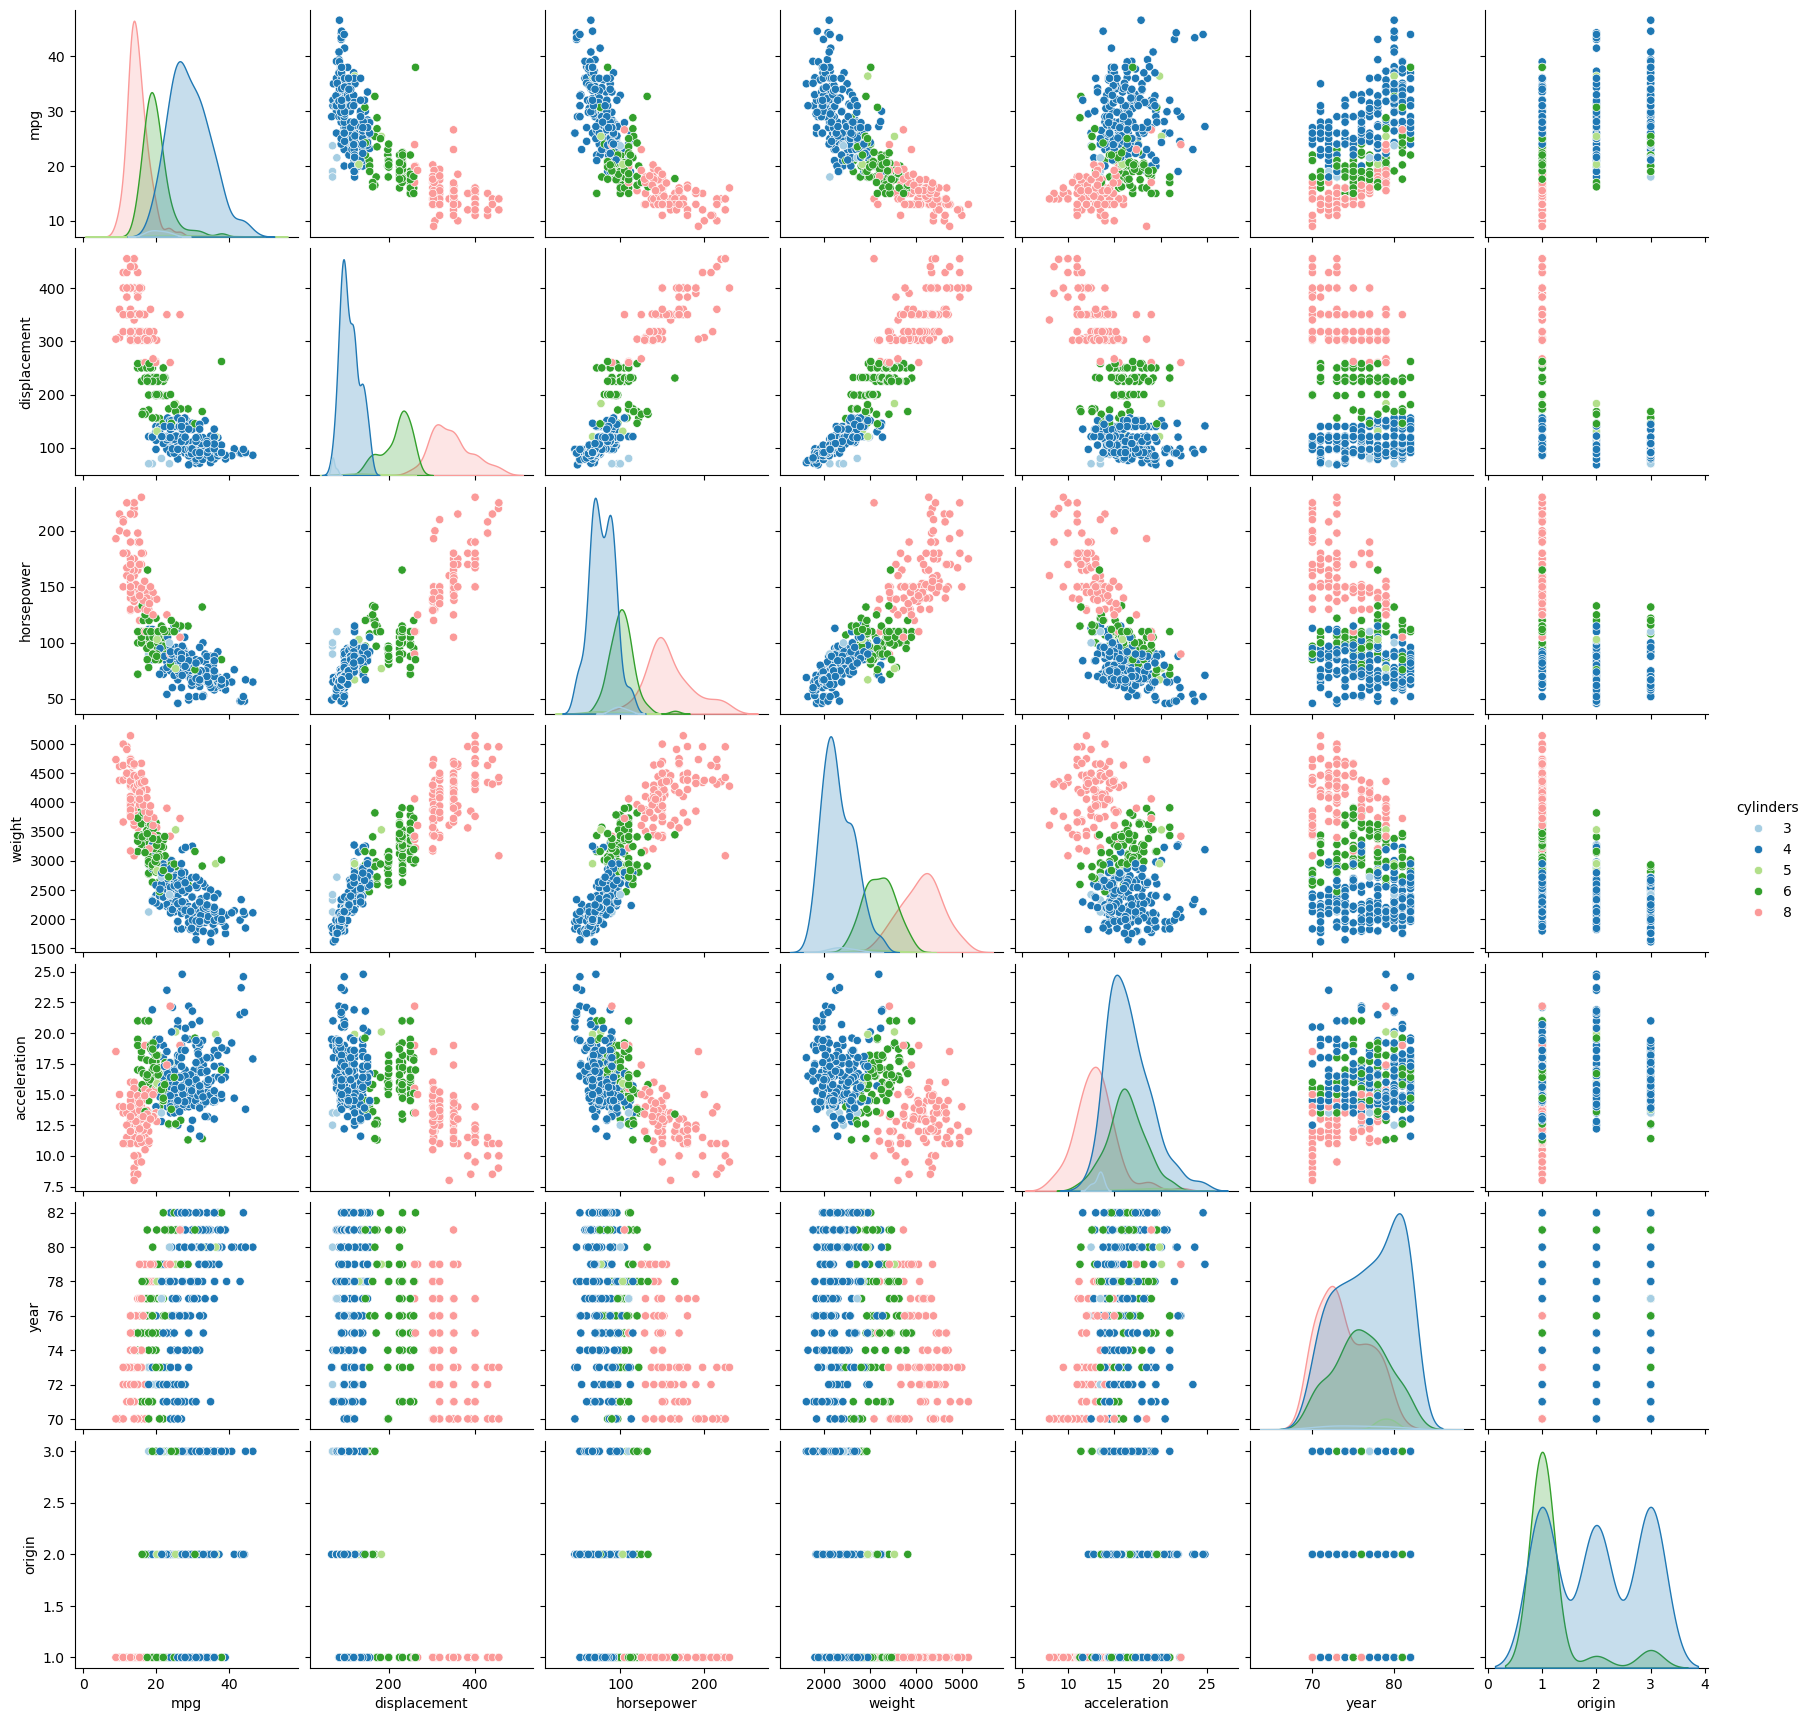

In [7]:
# Pairs plot
sns.pairplot(df, hue = 'cylinders', palette = 'Paired')
plt.show()

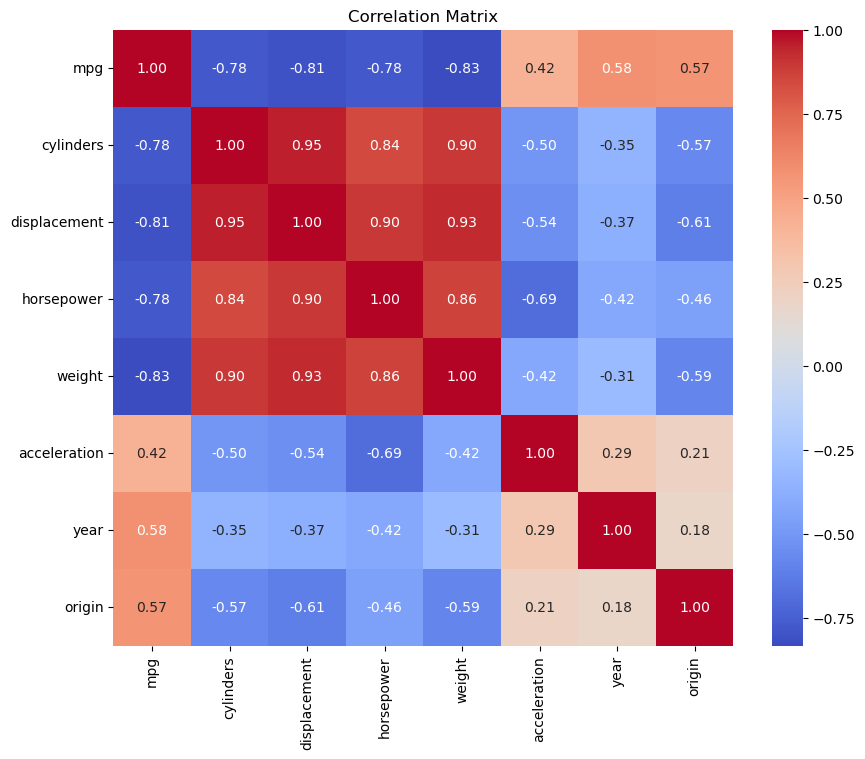

In [8]:
# Correlation matrix
correlation_matrix = df.corr() # Compute correlations
plt.figure(figsize=(10, 8)) # Adjust figure size
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title('Correlation Matrix')
plt.show()

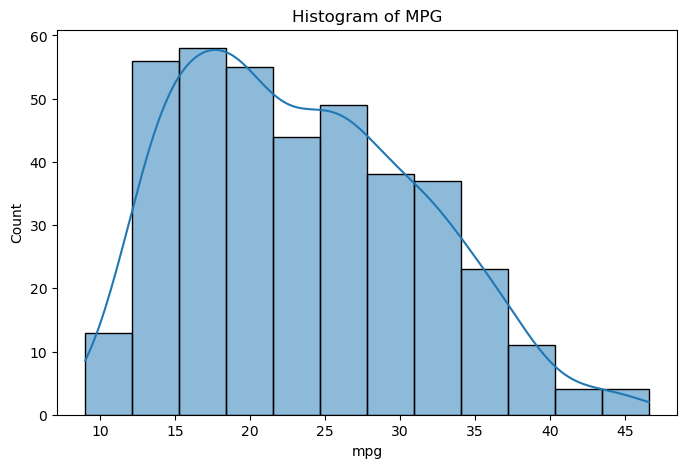

In [9]:
# Histogram of MPG
plt.figure(figsize = (8,5))
sns.histplot(df['mpg'], kde = True)
plt.title("Histogram of MPG")
plt.show()

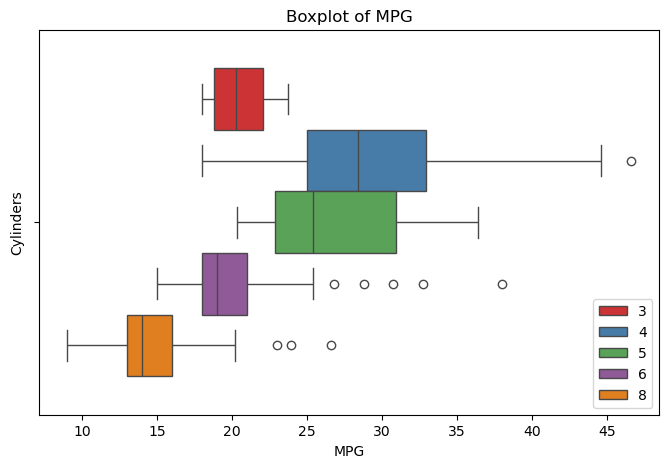

In [10]:
# Boxplots of MPG
plt.figure(figsize = (8,5))
sns.boxplot(x = 'mpg', data = df, hue = 'cylinders', palette = 'Set1')
plt.legend(loc = 'lower right')
plt.title('Boxplot of MPG')
plt.xlabel("MPG")
plt.ylabel("Cylinders")
plt.show()

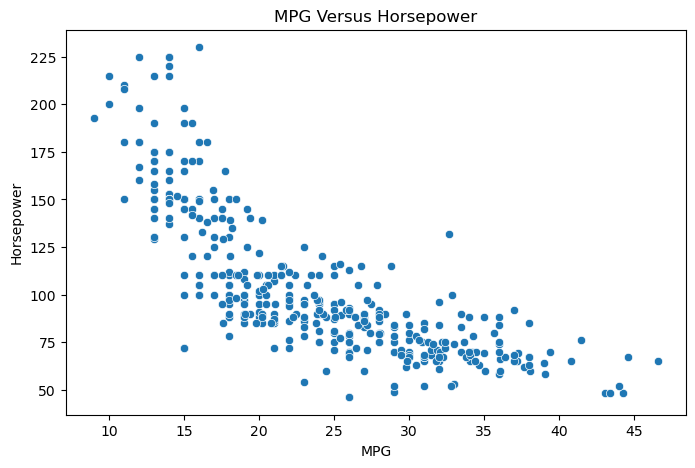

In [11]:
# MPG versus horsepower
plt.figure(figsize = (8,5))
sns.scatterplot(x = 'mpg', y = 'horsepower', data = df,)
plt.title('MPG Versus Horsepower')
plt.xlabel("MPG")
plt.ylabel("Horsepower")
plt.show()

<Figure size 800x500 with 0 Axes>

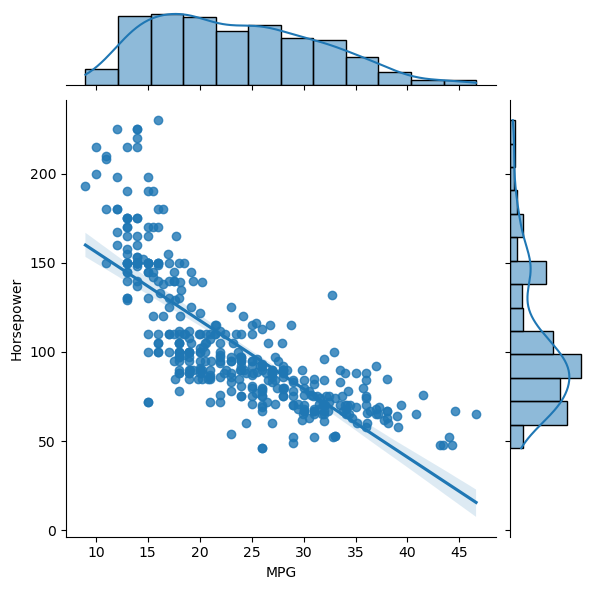

In [12]:
# MPG versus horsepower
plt.figure(figsize = (8,5))
sns.jointplot(x = 'mpg', y = 'horsepower', data = df, kind = 'reg')
plt.xlabel("MPG")
plt.ylabel("Horsepower")
plt.show()

In [13]:
# Define X and y portions of the dataset
X = df.drop(columns = ['mpg'])
y = df['mpg']

# Split the dataset 80/20
X_train, X_test, y_train, y_test = tts(X,
                                       y,
                                       train_size = 0.8,
                                       test_size = 0.2,
                                       shuffle = True,
                                       random_state = 42)

# Linear

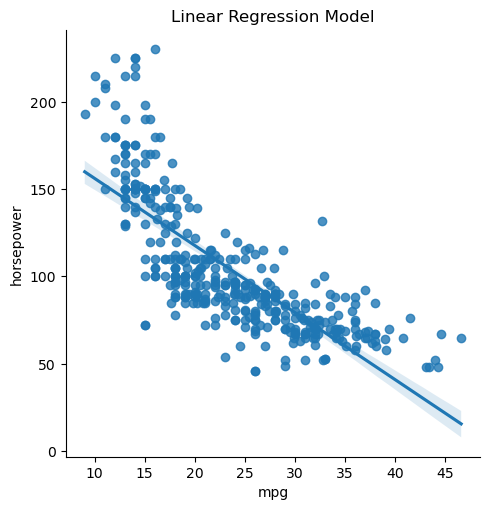

In [14]:
sns.lmplot(data = df, x = 'mpg', y = 'horsepower')
plt.title("Linear Regression Model")
plt.show()

#  Polynomials

In [15]:
for i in range (1,11):
    model = Pipeline([('poly', PolynomialFeatures(degree=i)), 
                      ('linear', LinearRegression())])
    model.fit(X,y)

    score = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

    print("Degree: %i  CV MSE: %.3f" % (i, np.mean(np.abs(score))))

Degree: 1  CV MSE: 15.061
Degree: 2  CV MSE: 11.787
Degree: 3  CV MSE: 46.815
Degree: 4  CV MSE: 19366.974
Degree: 5  CV MSE: 23400.080
Degree: 6  CV MSE: 95607.638
Degree: 7  CV MSE: 2699.084
Degree: 8  CV MSE: 446.962
Degree: 9  CV MSE: 8912.249
Degree: 10  CV MSE: 11082.599


### The degree of polynomial that best fits mpg is 2, since MSE is the lowest, at 11.787.

In [16]:
polyMPG = MS([poly('mpg', degree = 2)]).fit(df)
M = sm.OLS(y, polyMPG.transform(df)).fit()
summarize(M)

,coef,std err,t,P>|t|
intercept,2.344590e+01,6.210000e-16,3.770000e+16,0.0
"poly(mpg, degree=2)[0]",1.543340e+02,1.230000e-14,1.250000e+16,0.0
"poly(mpg, degree=2)[1]",-6.839000e-14,1.230000e-14,-5.560000e+00,0.0


<function matplotlib.pyplot.show(close=None, block=None)>

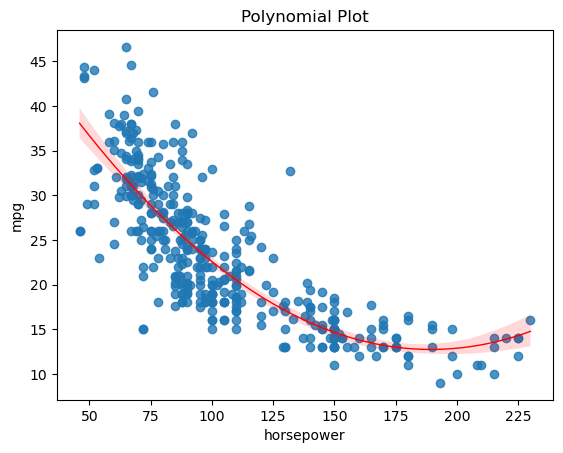

In [17]:
sns.regplot(data = df,
            x = 'horsepower',
            y = 'mpg', order = 2,
           line_kws = {'linewidth': 1,'color': 'red'})
plt.title('Polynomial Plot')
plt.show

# Steps

In [18]:
for i in range(1,11):
    groups = pd.cut(df['horsepower'], i)
    df_dummies = pd.get_dummies(groups)

    X_step = df_dummies
    y_step = df['mpg']

    model.fit(X_step, y_step)
    score = cross_val_score(model, X_step, y_step, cv=5, scoring='neg_mean_squared_error')

    print('Number of cuts: %i  CV MSE: %.3f' %(i, np.mean(np.abs(score))))

Number of cuts: 1  CV MSE: 73.925
Number of cuts: 2  CV MSE: 45.560
Number of cuts: 3  CV MSE: 41.083
Number of cuts: 4  CV MSE: 29.885
Number of cuts: 5  CV MSE: 27.621
Number of cuts: 6  CV MSE: 27.146
Number of cuts: 7  CV MSE: 26.221
Number of cuts: 8  CV MSE: 23.666
Number of cuts: 9  CV MSE: 25.289
Number of cuts: 10  CV MSE: 26.289


### The step function that fits best is that of 8 cuts, with the lowest MSE of 23.666.

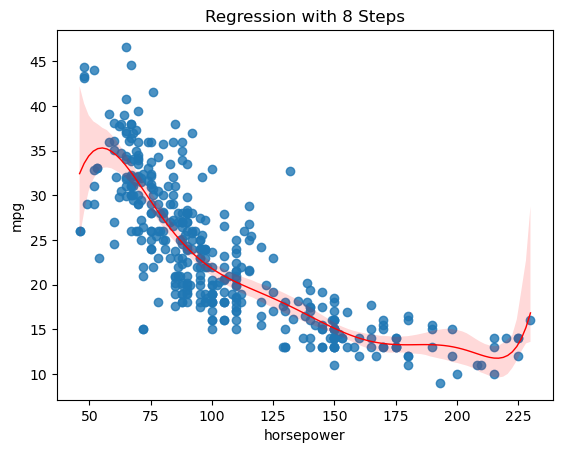

In [19]:
sns.regplot(data = df,
            x = 'horsepower',
            y = 'mpg', order = 8,
           line_kws = {'linewidth': 1,'color': 'red'})
plt.title('Regression with 8 Steps')
plt.show()